In [12]:
import warnings
import itertools
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [13]:
telemetry = pd.read_csv('PdM_telemetry.csv')
telemetry

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511
...,...,...,...,...,...,...
876095,2016-01-01 02:00:00,100,179.438162,395.222827,102.290715,50.771941
876096,2016-01-01 03:00:00,100,189.617555,446.207972,98.180607,35.123072
876097,2016-01-01 04:00:00,100,192.483414,447.816524,94.132837,48.314561
876098,2016-01-01 05:00:00,100,165.475310,413.771670,104.081073,44.835259


## Vibration forcasting for machine 1 daily, weekly and monthly

In [14]:
df = telemetry[telemetry["machineID"] == 1][["datetime", "vibration"]]
df.head(24)

,datetime,vibration
0,2015-01-01 06:00:00,45.087686
1,2015-01-01 07:00:00,43.413973
2,2015-01-01 08:00:00,34.178847
3,2015-01-01 09:00:00,41.122144
4,2015-01-01 10:00:00,25.990511
5,2015-01-01 11:00:00,35.655017
6,2015-01-01 12:00:00,42.753920
7,2015-01-01 13:00:00,35.482009
8,2015-01-01 14:00:00,45.482287
9,2015-01-01 15:00:00,39.901735


In [15]:
vibration = pd.DataFrame(data=df, columns=['vibration'])
vibration.ffill(inplace=True)
vibration['vibration'] = vibration['vibration'].astype(float).astype(int)
print(vibration)

      vibration
0            45
1            43
2            34
3            41
4            25
...         ...
8756         43
8757         42
8758         33
8759         46
8760         37

[8761 rows x 1 columns]


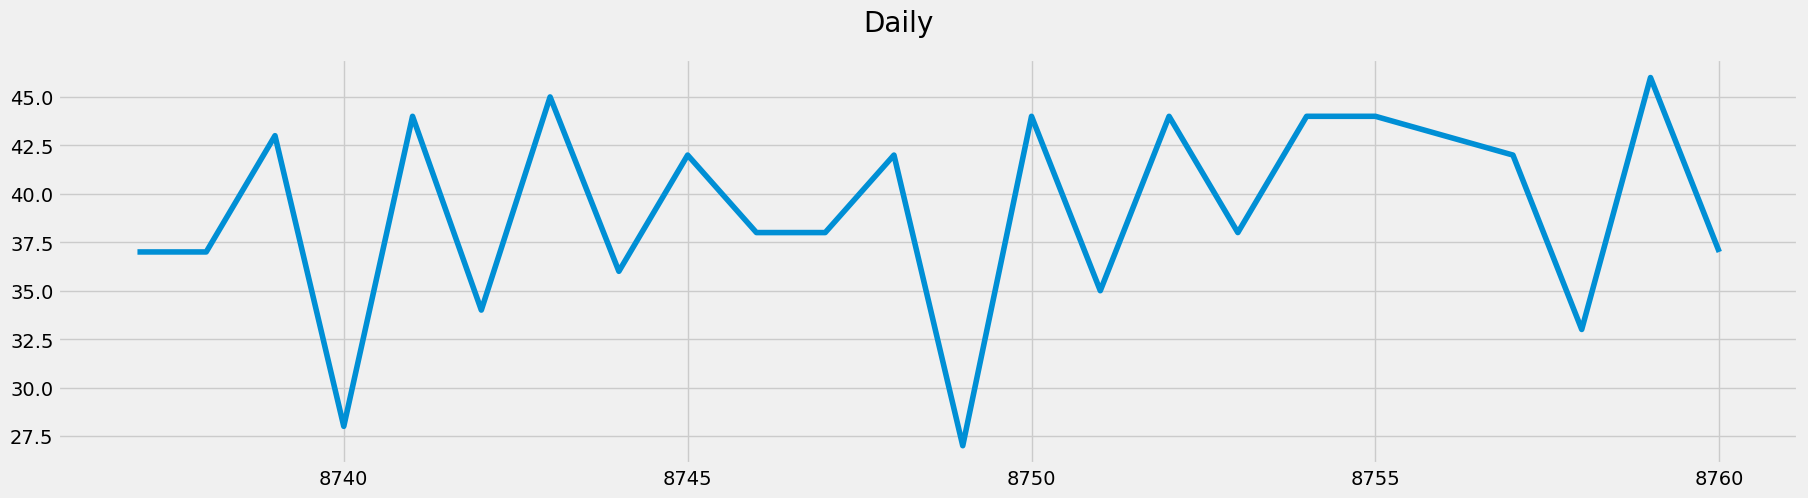

In [16]:
plt.figure(figsize=(20,5)).suptitle("Daily", fontsize=20)
plt.plot(vibration['vibration'].tail(24))

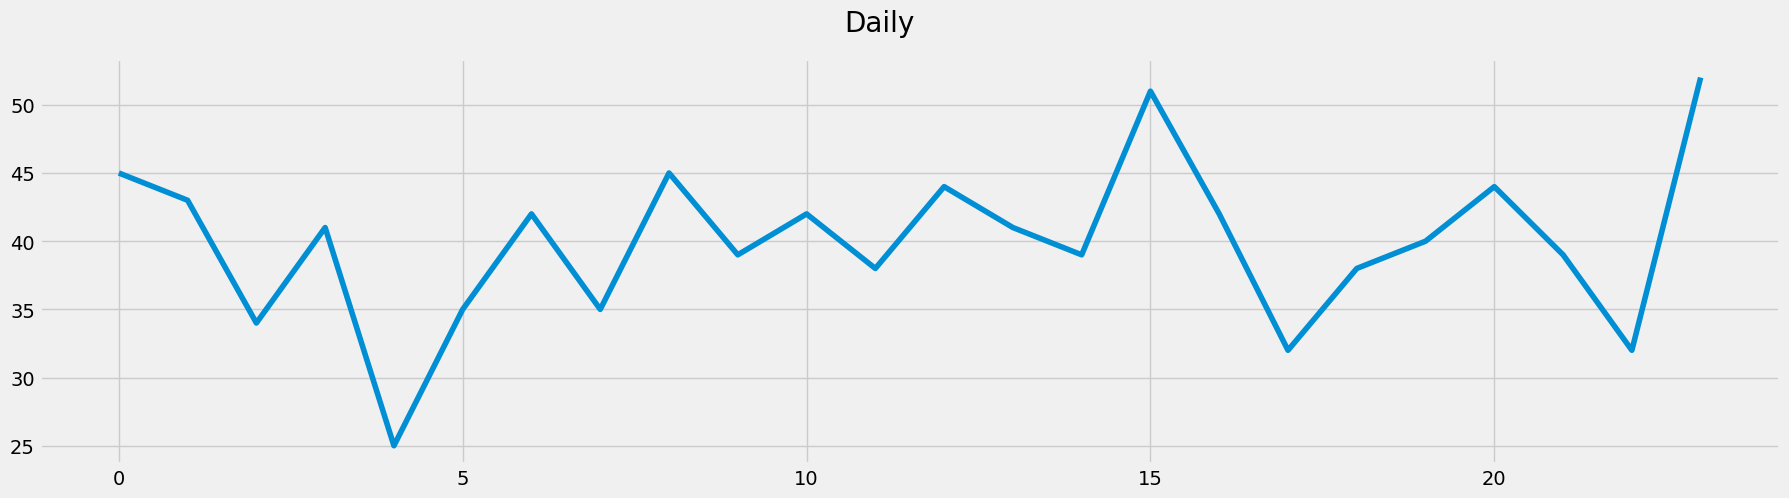

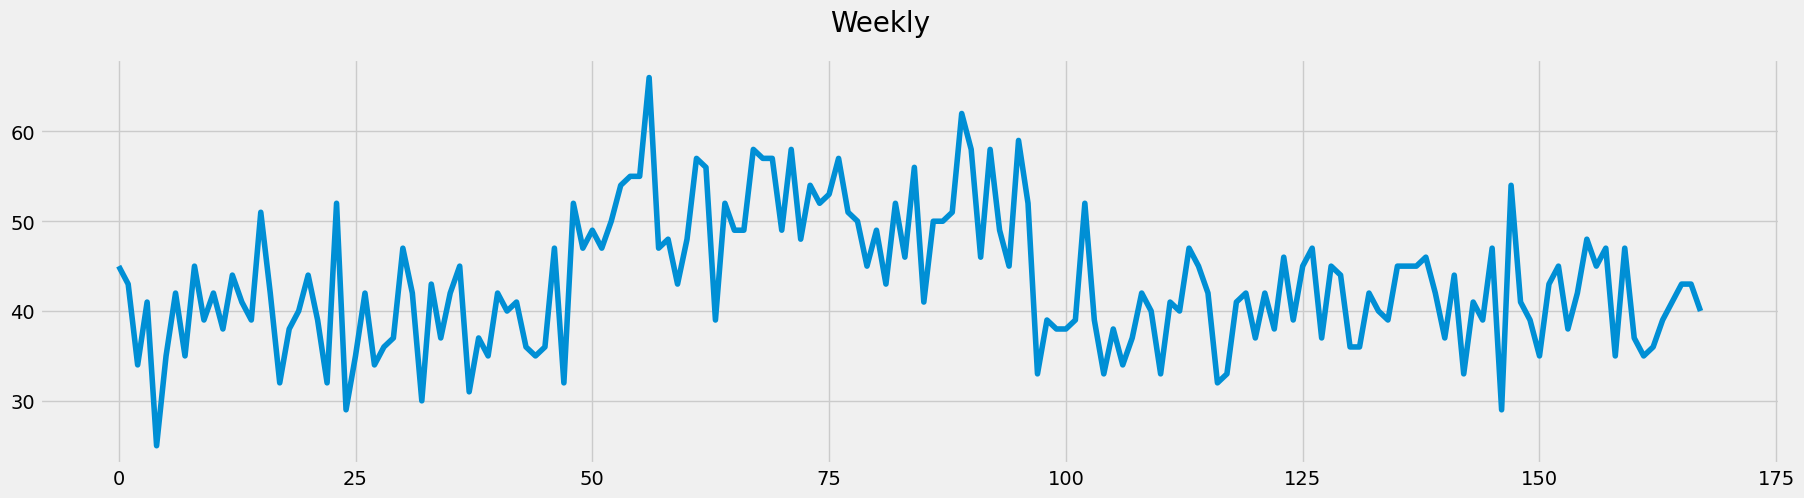

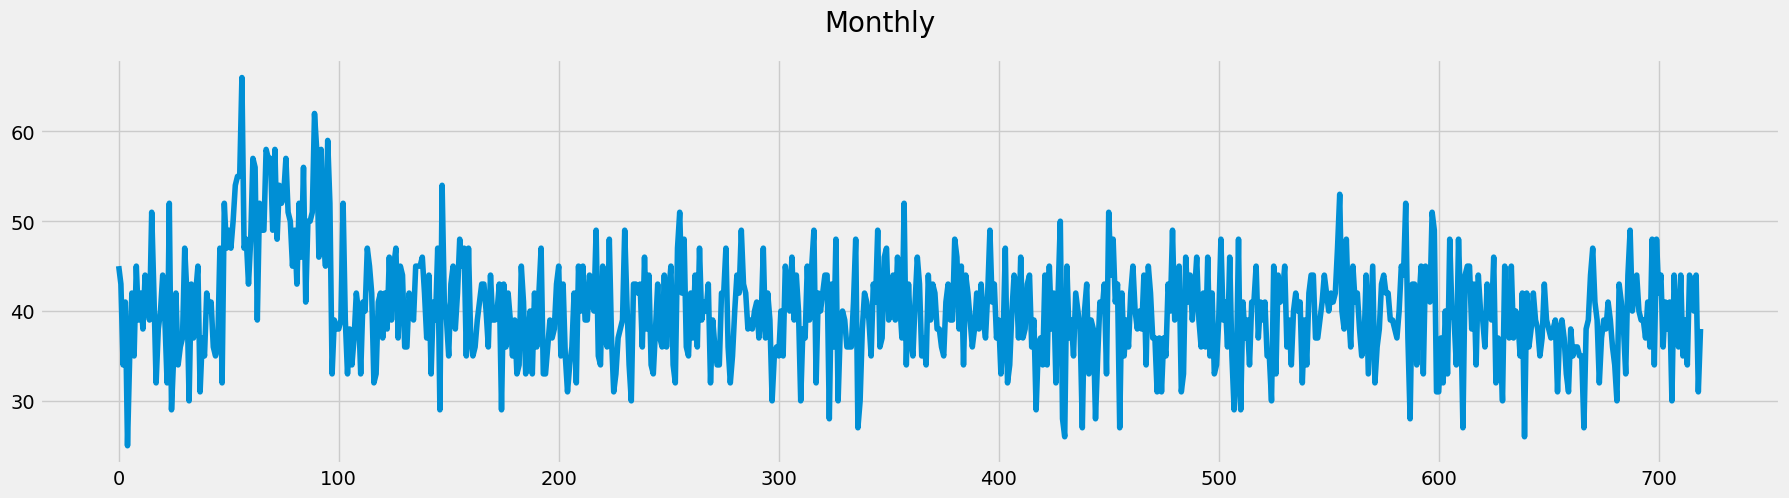

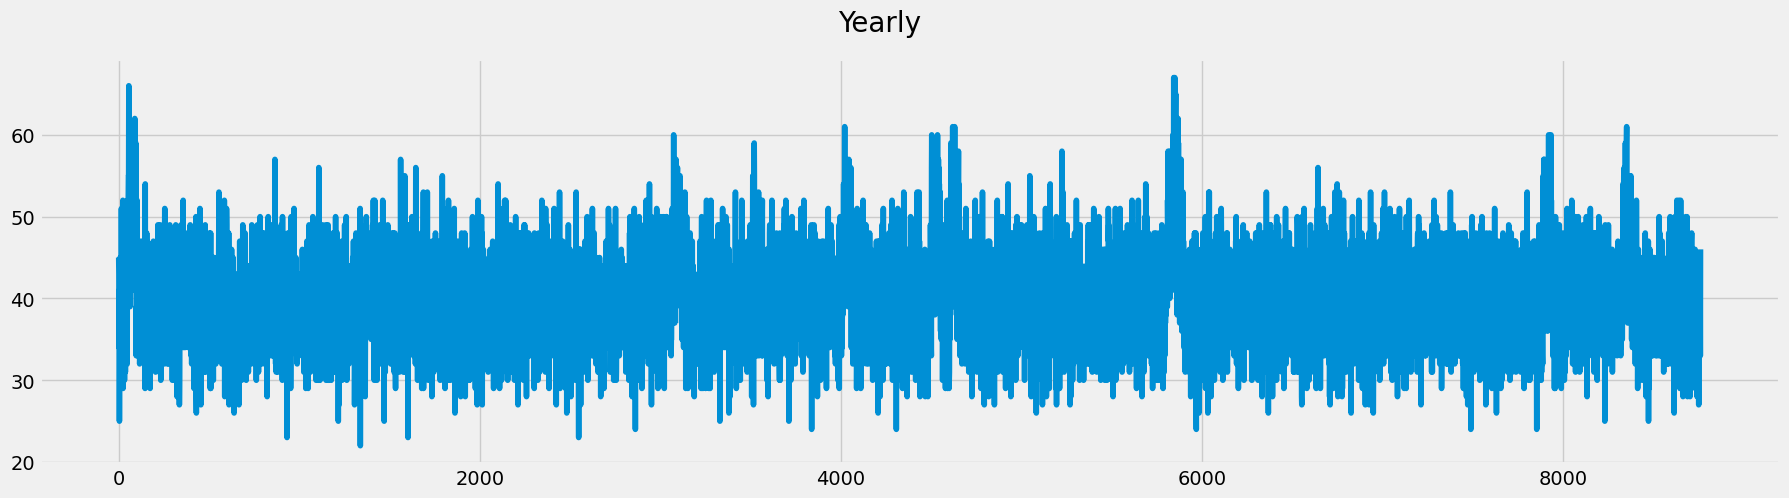

In [17]:
plt.figure(figsize=(20,5)).suptitle("Daily", fontsize=20)
plt.plot(vibration['vibration'].head(24))

plt.figure(figsize=(20,5)).suptitle("Weekly", fontsize=20)
plt.plot(vibration['vibration'].head(168))

plt.figure(figsize=(20,5)).suptitle("Monthly", fontsize=20)
plt.plot(vibration['vibration'].head(720))

plt.figure(figsize=(20,5)).suptitle("Yearly", fontsize=20)
plt.plot(vibration['vibration'].head(8760))

In [18]:
from sklearn.preprocessing import StandardScaler
#Scale data
print("Vibration Range before scaling : ",
      min(vibration.vibration),
      max(vibration.vibration))

scaler = StandardScaler()
scaled_vibration = scaler.fit_transform(vibration)
print("Vibration Range after scaling : ",
      min(scaled_vibration),
      max(scaled_vibration))

train_size = 8041
lookback = 720

train_vibration = scaled_vibration[0:train_size,:]
test_vibration = scaled_vibration[train_size-lookback:,:]

print("\n Shaped of train and test :",
      train_vibration.shape, test_vibration.shape)

Vibration Range before scaling :  22 67
Vibration Range after scaling :  [-3.25615666] [4.84938636]

 Shaped of train and test : (8041, 1) (1440, 1)


In [19]:
# Prepare RNN dataset
def create_rnn_dataset(data, lookback=1):
    data_x, data_y = [], []
    for i in range(len(data) - lookback -1):
        a = data[i:(i + lookback), 0]
        data_x.append(a)
        data_y.append(data[i + lookback, 0])
    return np.array(data_x), np.array(data_y)

train_req_x, train_req_y = create_rnn_dataset(train_vibration,lookback)

train_req_x = np.reshape(train_req_x,
                            (train_req_x.shape[0],1, train_req_x.shape[1]))

print("Shapes of X and Y: ", train_req_x.shape, train_req_y.shape)
        

Shapes of X and Y:  (7320, 1, 720) (7320,)


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf

tf.random.set_seed(3)
ts_model=Sequential()
#add lstm
ts_model.add(LSTM(256, input_shape=(1, lookback)))
ts_model.add(Dense(1))
ts_model.compile(loss="mean_squared_error",
                optimizer='adam',
                metrics=["mse"])
ts_model.summary()
ts_model.fit(train_req_x, train_req_y,
            epochs=20, batch_size=1, verbose=1)

2025-10-11 23:27:04.501764: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-11 23:27:04.525405: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-11 23:27:05.160987: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1760221625.544800   57975 gpu_device.cc:2342] Cannot dlopen some GPU libraries.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 256)            │     1,000,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,705 (3.82 MB)

 Trainable params: 1,000,705 (3.82 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.9672 - mse: 0.9672
Epoch 2/20
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.4941 - mse: 0.4941
Epoch 3/20
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.2662 - mse: 0.2662
Epoch 4/20
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.2473 - mse: 0.2473
Epoch 5/20
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.1652 - mse: 0.1652
Epoch 6/20
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.1674 - mse: 0.1674
Epoch 7/20
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.1408 - mse: 0.1408
Epoch 8/20
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.1310 - mse: 0.1310
Epoch 9/20
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.1155 - mse: 0.1155
Epoch 10/20
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.1083 - mse: 0.1083
Epoch 11/20
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.1001 - mse: 0.1001
Epoch 12/20
7320/7320 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0978 - m

In [21]:
test_req_x, test_req_y = create_rnn_dataset(test_vibration, lookback)
test_req_x = np.reshape(test_req_x,
                       (test_req_x.shape[0],1,test_req_x.shape[1]))
ts_model.evaluate(test_req_x, test_req_y, verbose=1)

predict_on_train = ts_model.predict(train_req_x)
predict_on_test = ts_model.predict(test_req_x)

predict_on_train = scaler.inverse_transform(predict_on_train)
predict_on_test = scaler.inverse_transform(predict_on_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0624 - mse: 1.0624  
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


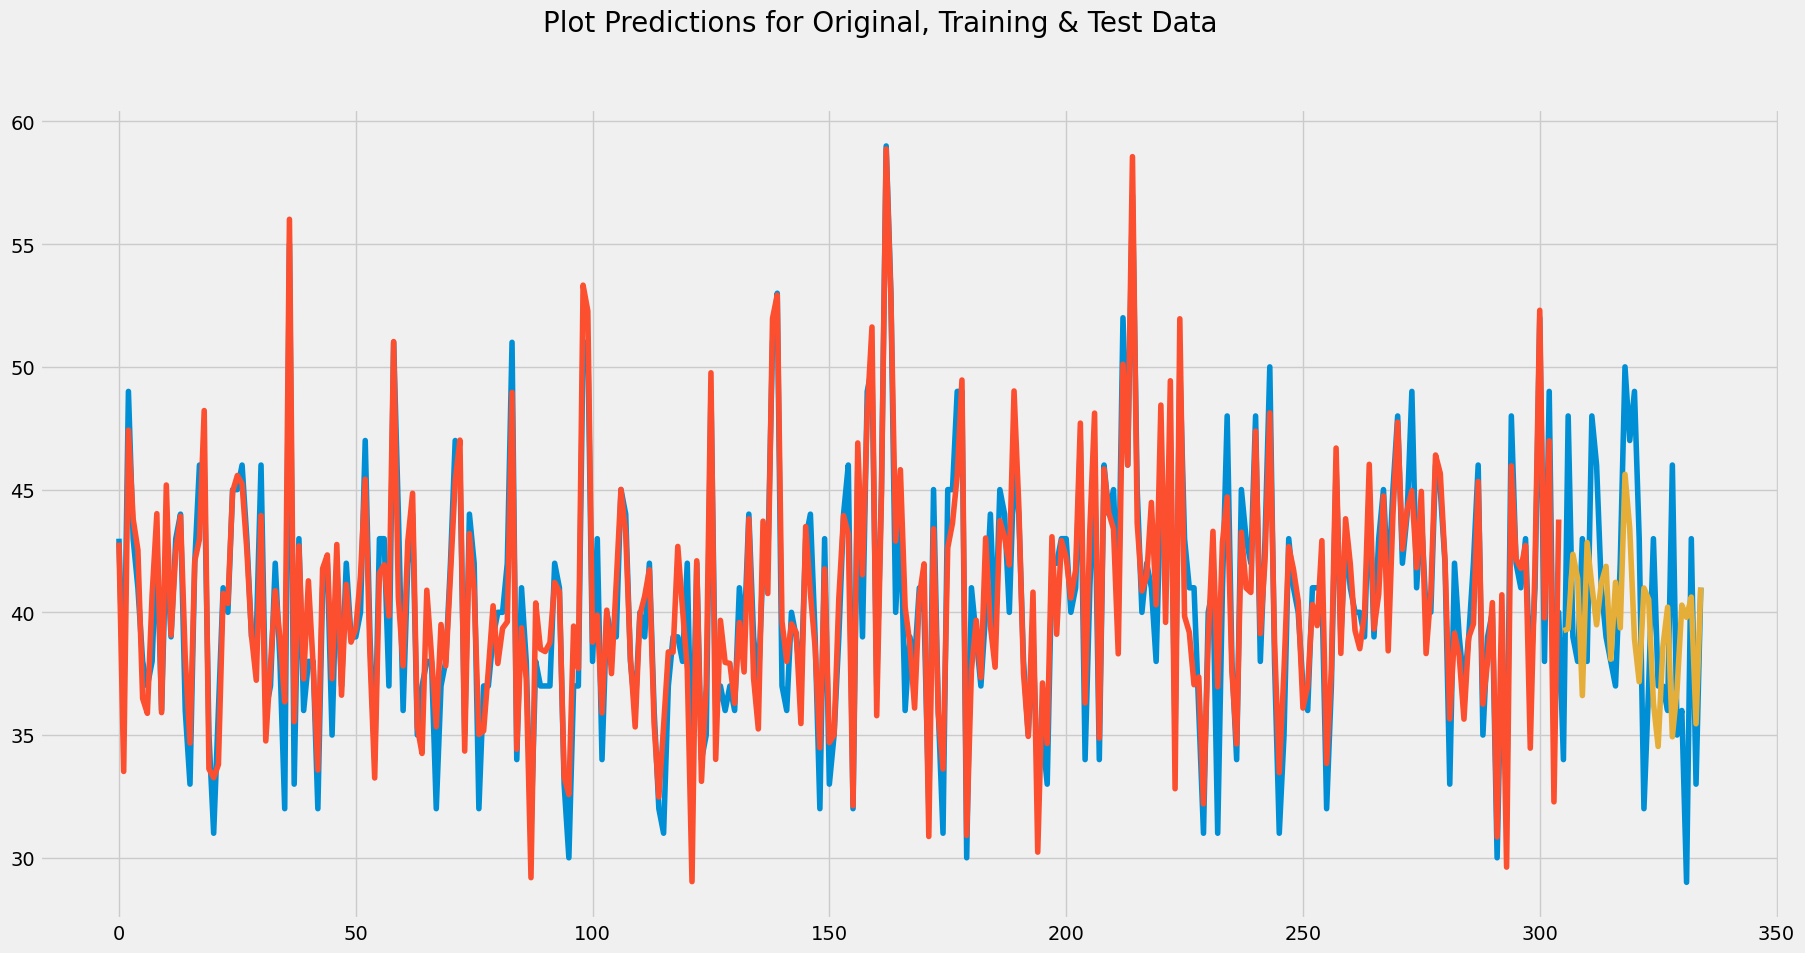

In [22]:
# Plot the predictions

# Total size of plot
total_size = len(predict_on_train) + len(predict_on_test)

# plot original data
orig_data = vibration.vibration.to_numpy()
orig_data = orig_data.reshape(len(orig_data), 1)

# Create a plot for original data
orig_plot = np.empty((total_size, 1))
orig_plot[:, :] = np.nan
orig_plot[0:total_size, :] = orig_data[lookback:-2,]

# Create a plot for predictions on training
predict_train_plot = np.empty((total_size, 1))
predict_train_plot[:, :] = np.nan
predict_train_plot[0:len(predict_on_train), :] = predict_on_train

# Create a plot for predictions on testing
predict_test_plot = np.empty((total_size, 1))
predict_test_plot[:, :] = np.nan
predict_test_plot[len(predict_on_train):total_size, :] = predict_on_test

# Plot the graphs
plt.figure(figsize=(20, 10)).suptitle("Plot Predictions for Original, Training & Test Data", fontsize=20)
plt.plot(orig_plot[::24])
plt.plot(predict_train_plot[::24])
plt.plot(predict_test_plot[::24])
plt.show()

In [23]:
curr_input = test_req_x[1, :].flatten()

# Predict for the hours
predict_for = 24*30

for i in range(predict_for):
    
    this_input = curr_input[-lookback:]
    this_input = this_input.reshape((1, 1, lookback))
    this_prediction = ts_model.predict(this_input)
    
    curr_input = np.append(curr_input, this_prediction.flatten())

predict_on_future = np.reshape(np.array(curr_input[-predict_for:]), (predict_for, 1))
predict_on_future = scaler.inverse_transform(predict_on_future)

print(predict_on_future[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━

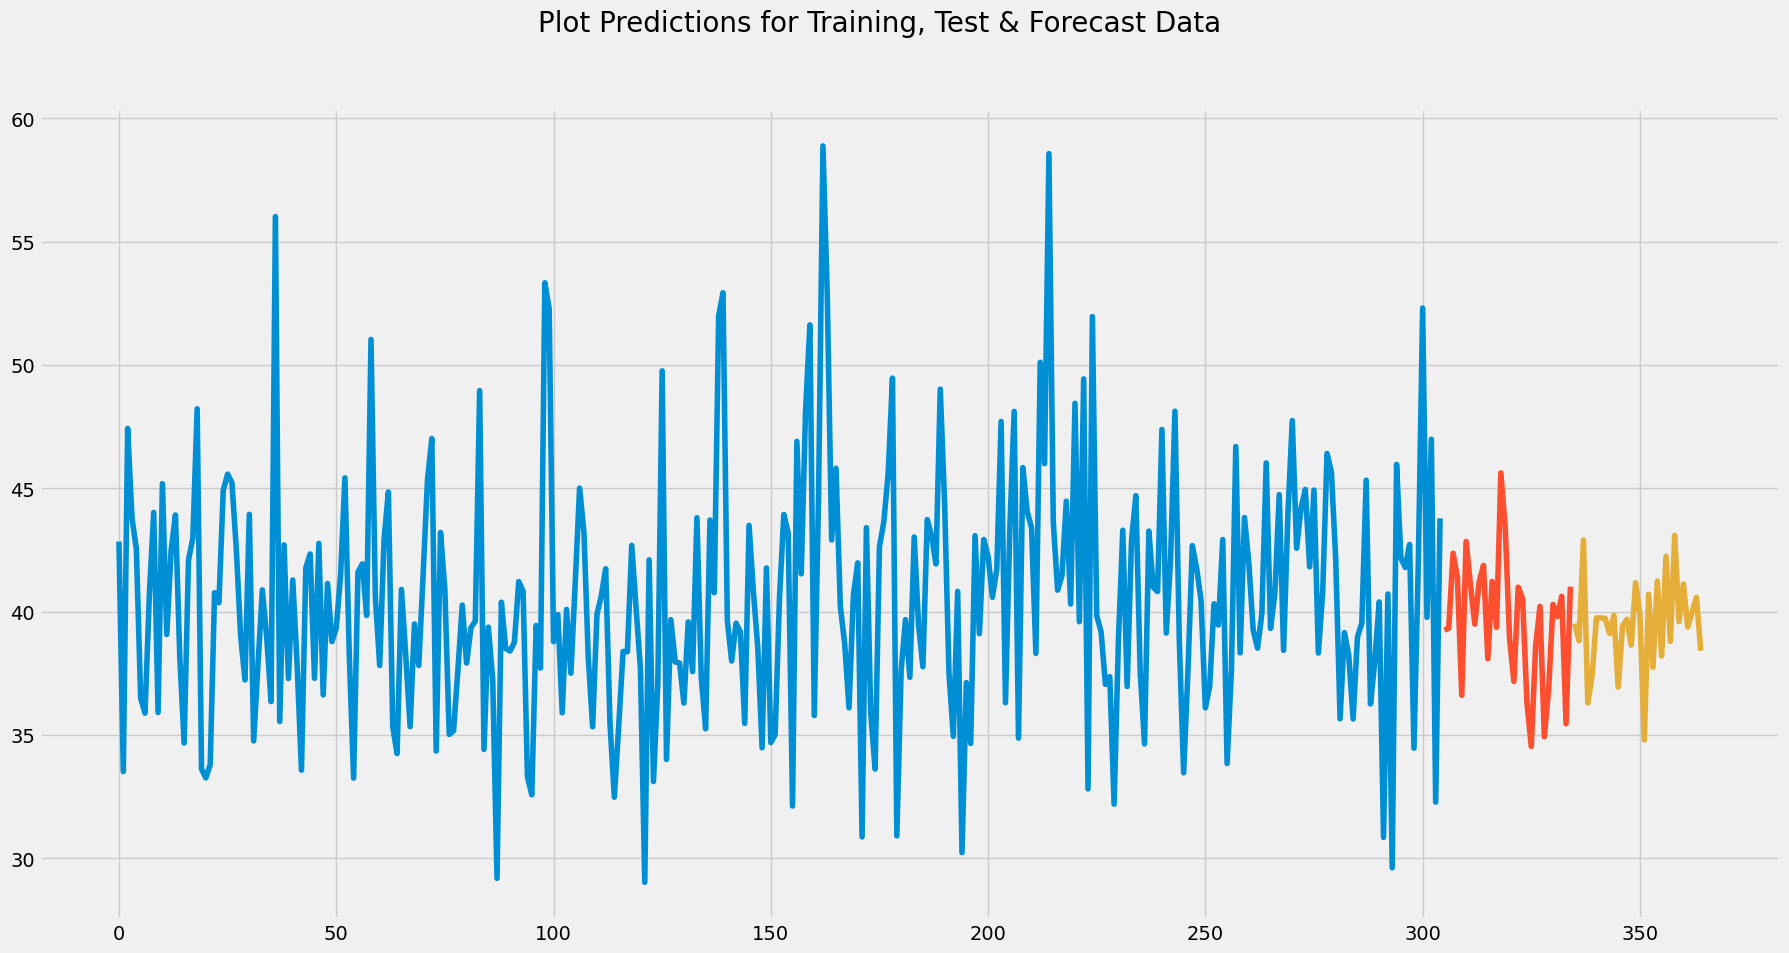

In [24]:
# Plot the training data with the forecast data
total_size = len(predict_on_train) + len(predict_on_test) + len(predict_on_future)

# Setup training chart
predict_train_plot = np.empty((total_size, 1))
predict_train_plot[:, :] = np.nan
predict_train_plot[0:len(predict_on_train), :] = predict_on_train

# Setup test chart
predict_test_plot = np.empty((total_size, 1))
predict_test_plot[:, :] = np.nan
predict_test_plot[len(predict_on_train):len(predict_on_train)+len(predict_on_test), :] = predict_on_test

# Setup future forecast chart
predict_future_plot = np.empty((total_size, 1))
predict_future_plot[:, :] = np.nan
predict_future_plot[len(predict_on_train)+len(predict_on_test):total_size, :] = predict_on_future

plt.figure(figsize=(20, 10)).suptitle("Plot Predictions for Training, Test & Forecast Data", fontsize=20)
plt.plot(predict_train_plot[::24])
plt.plot(predict_test_plot[::24])
plt.plot(predict_future_plot[::24])
plt.show()


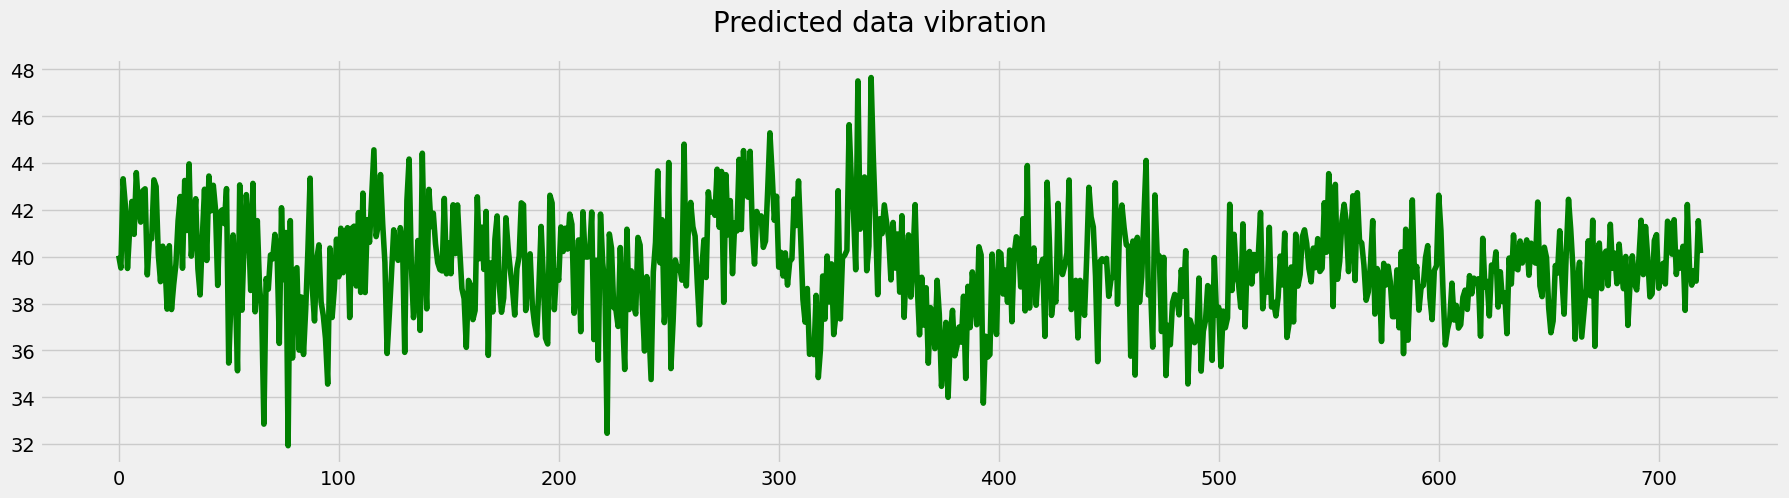

In [25]:
plt.figure(figsize=(20,5)).suptitle("Predicted data vibration", fontsize=20)
plt.plot(predict_on_future, color='g')
plt.show()


['2016-01-01 07:00', '2016-01-01 08:00', '2016-01-01 09:00', '2016-01-01 10:00', '2016-01-01 11:00', '2016-01-01 12:00', '2016-01-01 13:00', '2016-01-01 14:00', '2016-01-01 15:00', '2016-01-01 16:00', '2016-01-01 17:00', '2016-01-01 18:00', '2016-01-01 19:00', '2016-01-01 20:00', '2016-01-01 21:00', '2016-01-01 22:00', '2016-01-01 23:00', '2016-01-02 00:00', '2016-01-02 01:00', '2016-01-02 02:00', '2016-01-02 03:00', '2016-01-02 04:00', '2016-01-02 05:00', '2016-01-02 06:00', '2016-01-02 07:00']


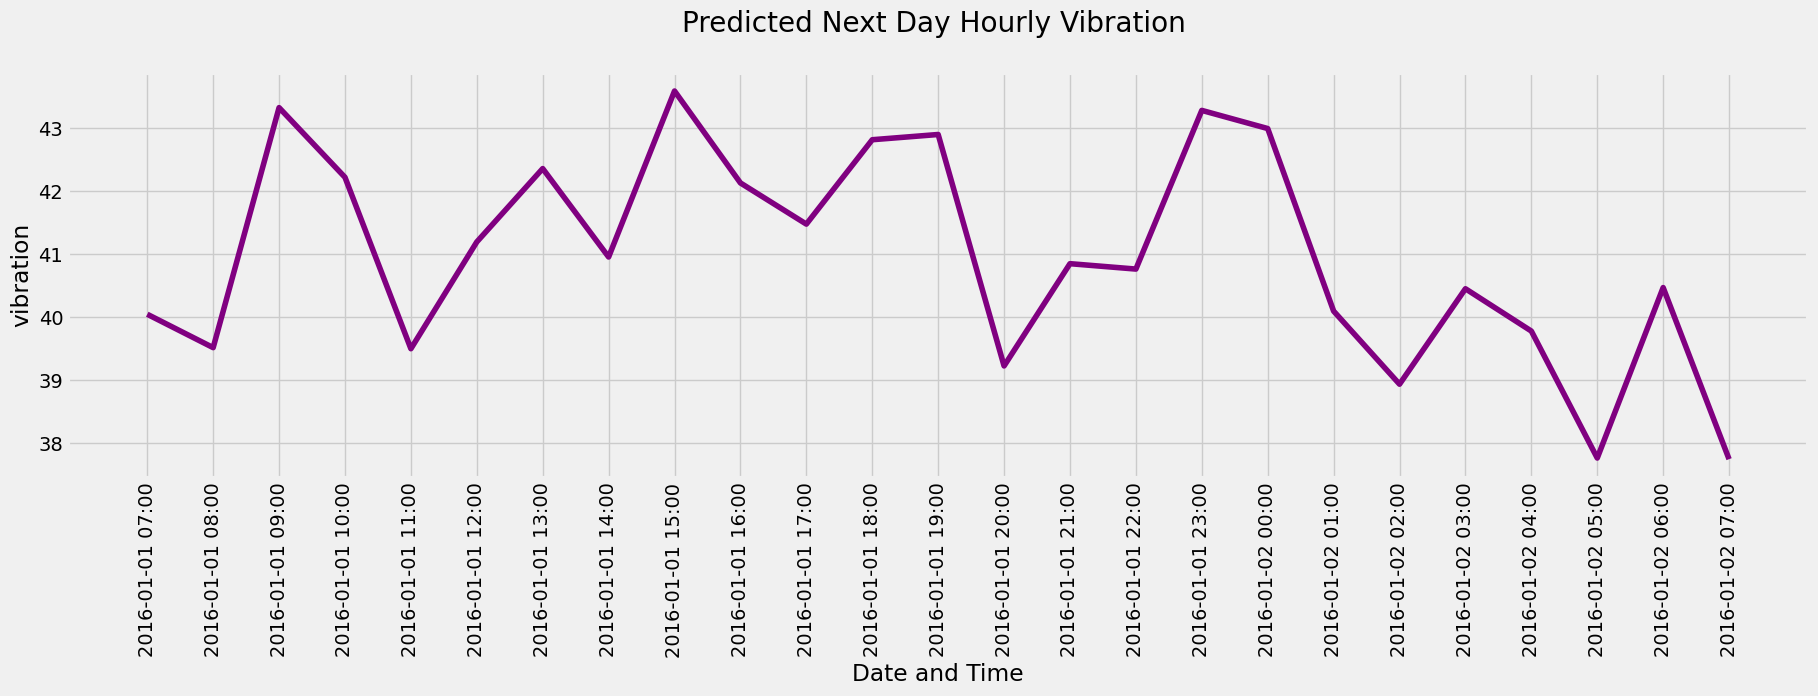

In [26]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

def daterange(start_date, end_date):
    delta = timedelta(hours=1)
    while start_date < end_date:
        yield start_date
        start_date += delta

predicted_dates = []

# ✅ Remove leading zeros
start_date = datetime(2016, 1, 1, 7, 0)   
end_date   = datetime(2017, 1, 1, 6, 0)  

for single_date in daterange(start_date, end_date):
    d = single_date.strftime("%Y-%m-%d %H:%M")
    predicted_dates.append(d)

print(predicted_dates[:25])  # just check first 25

# Example y_values (replace with your predictions)
y_values = predict_on_future[:25]

# Plot
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(y_values, color='purple')

# Set labels
ax.set(xlabel="Date and Time",
       ylabel="vibration",
       title="Predicted Next Day Hourly Vibration \n ")

day_points = list(range(25))
plt.xticks(day_points, predicted_dates[:25], rotation='vertical')
plt.show()


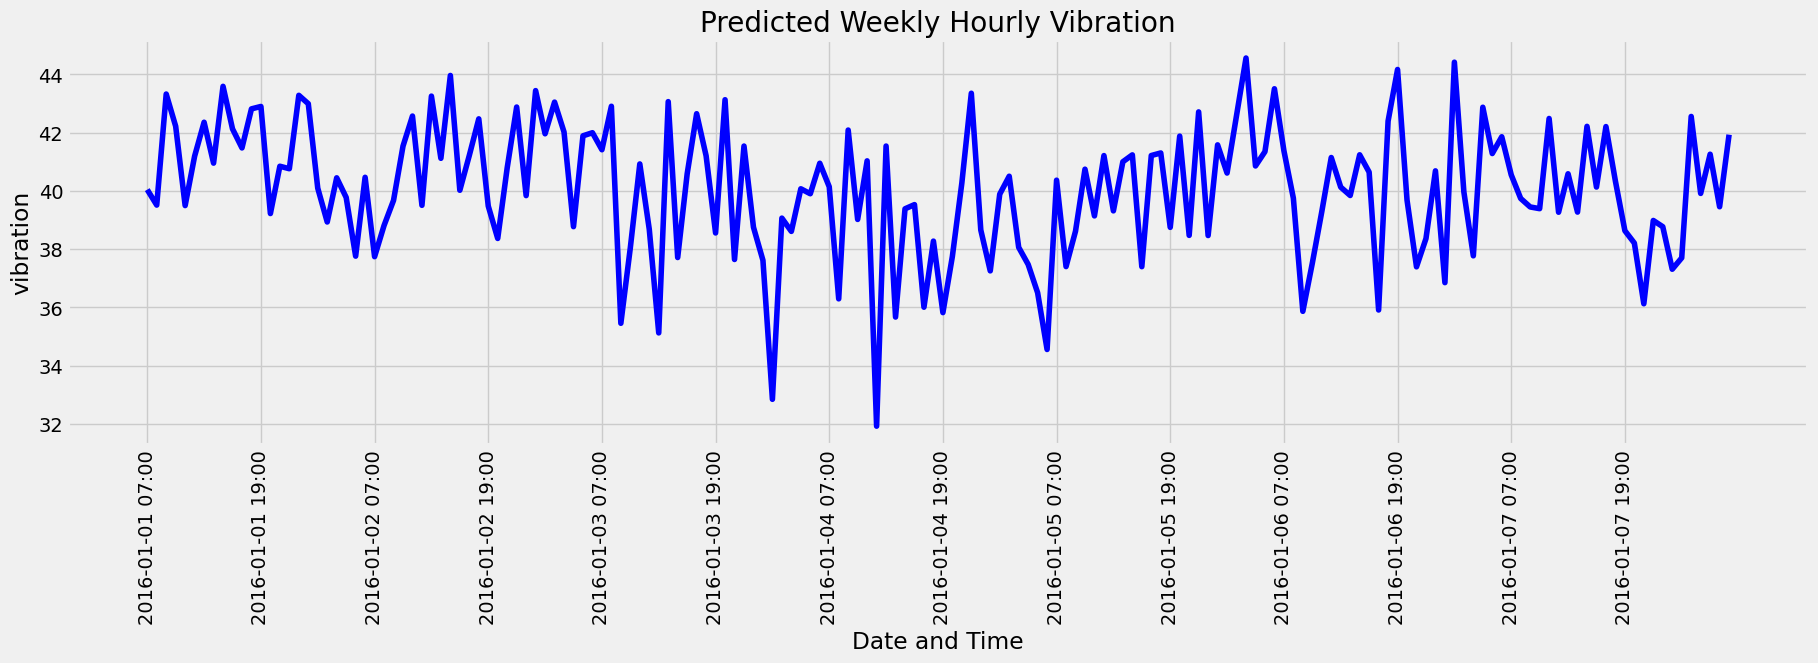

In [27]:
# Weekly (7 days = 168 hours)
y_values_week = predict_on_future[:168]   # first 168 predictions
dates_week = predicted_dates[:168]        # first 168 hourly timestamps

fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(y_values_week, color='blue')
ax.set(xlabel="Date and Time",
       ylabel="vibration",
       title="Predicted Weekly Hourly Vibration")
plt.xticks(list(range(0, 168, 12)), dates_week[::12], rotation='vertical')  
plt.show()

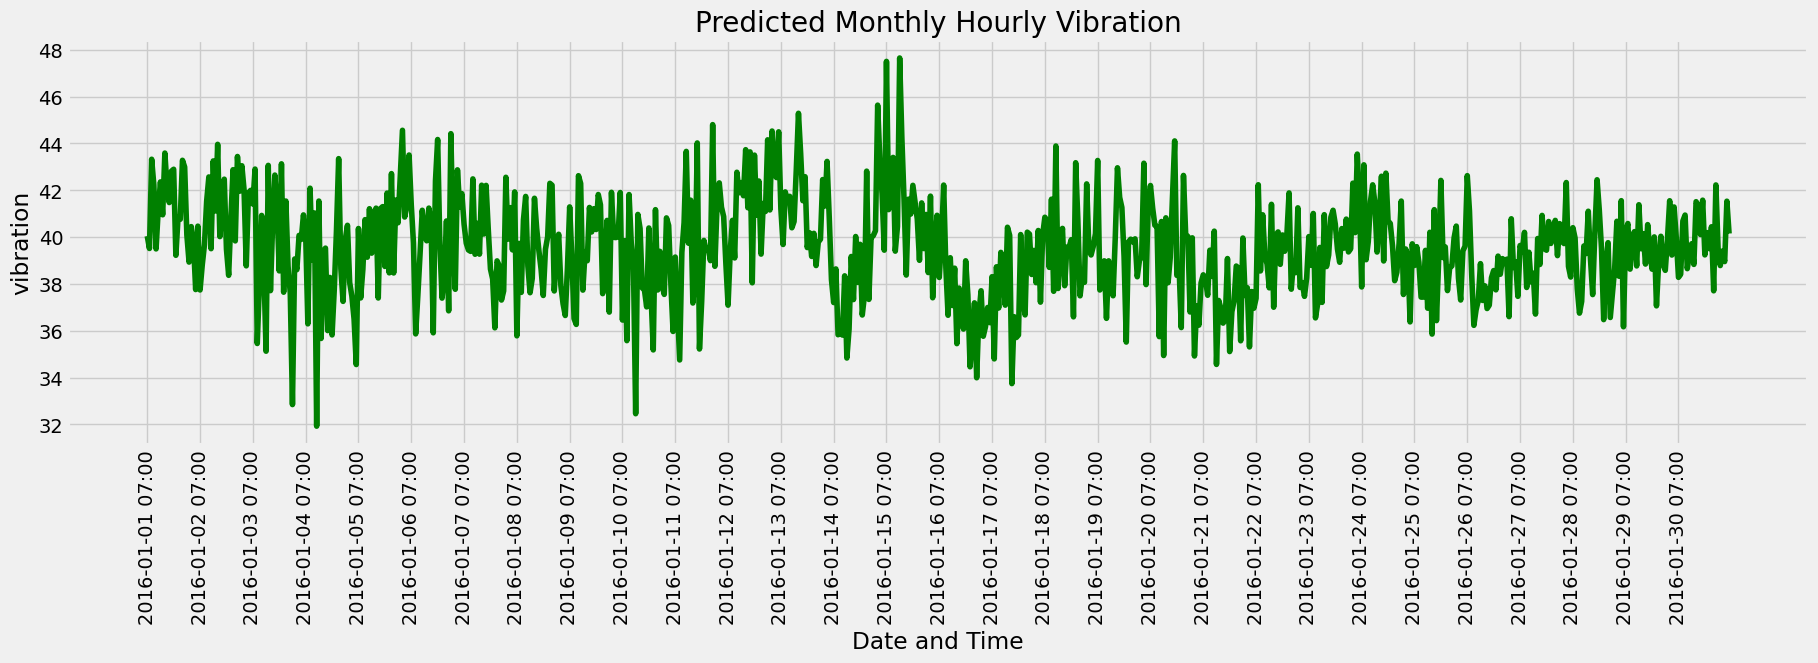

In [28]:
# Monthly (30 days = 720 hours)
y_values_month = predict_on_future[:720]   # first 720 predictions
dates_month = predicted_dates[:720]        # first 720 hourly timestamps

fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(y_values_month, color='green')
ax.set(xlabel="Date and Time",
       ylabel="vibration",
       title="Predicted Monthly Hourly Vibration")
plt.xticks(list(range(0, 720, 24)), dates_month[::24], rotation='vertical')  
plt.show()